In [1]:
import jax
import jax.numpy as jnp
import matplotlib.colors
import matplotlib.patches
import numpy as np
from matplotlib import pyplot as plt

from xxm.core.affine import Affine
from xxm.core.align import match_states_by_conditional_mean
from xxm.core.dists.categorical import Categorical
from xxm.core.dists.poisson import LinearPoisson
from xxm.core.emissions.discrete_ar import (
    AREmissions,
    flatten_ar_coefficients,
)
from xxm.core.models.discrete import CategoricalInitial, CategoricalTransitions
from xxm.hmm.inference import infer_exact
from xxm.hmm.init import init_poisson_ar
from xxm.hmm.learning import fit_em
from xxm.hmm.model import Model

In [2]:
NUM_NEURONS = 10
NUM_TIME_STEPS = 5000
STATES_CMAP = matplotlib.colors.ListedColormap(['tab:blue', 'tab:orange', 'tab:green'])


def make_true_model_bimodal(num_neurons):

    baseline = jnp.full(num_neurons, 8.0)

    # Deterministic 2D population subspace.
    angles = jnp.linspace(0, 2 * jnp.pi, num_neurons, endpoint=False)
    basis = jnp.stack(
        [
            jnp.cos(angles),
            jnp.sin(angles),
        ],
        axis=1,
    )
    basis, _ = jnp.linalg.qr(basis)  # (N, 2)

    local_dynamics_2d = jnp.array(
        [
            # clockwise
            [
                [0.60, 0.25],
                [-0.25, 0.60],
            ],
            # counter-clockwise
            [
                [0.60, -0.25],
                [0.25, 0.60],
            ],
        ]
    )

    projection = basis @ basis.T
    orthogonal_projection = jnp.eye(num_neurons) - projection

    local_dynamics = jax.vmap(
        lambda dynamics: basis @ dynamics @ basis.T + 0.2 * orthogonal_projection
    )(local_dynamics_2d)  # (K, N, N)

    coefficients = (local_dynamics / baseline[:, None])[:, None, :, :]  # (K, L=1, N, N)

    biases = jnp.log(baseline)[None, :] - jnp.einsum(
        'knm,m->kn',
        coefficients[:, 0],
        baseline,
    )

    model = Model(
        initial=CategoricalInitial(
            Categorical(probs=jnp.array([0.4, 0.6])),
        ),
        transitions=CategoricalTransitions(
            Categorical(
                jnp.array(
                    [
                        [0.98, 0.02],
                        [0.02, 0.98],
                    ]
                )
            )
        ),
        emissions=AREmissions(
            LinearPoisson(
                Affine(
                    coefficients=flatten_ar_coefficients(coefficients),
                    bias=biases,
                )
            )
        ),
    )

    return model, basis, baseline


def make_true_model_monomodal(num_neurons):

    baseline = jnp.full(num_neurons, 8.0)

    # Deterministic 2D population subspace.
    angles = jnp.linspace(0, 2 * jnp.pi, num_neurons, endpoint=False)
    basis = jnp.stack(
        [
            jnp.cos(angles),
            jnp.sin(angles),
        ],
        axis=1,
    )
    basis, _ = jnp.linalg.qr(basis)  # (N, 2)

    local_dynamics_2d = jnp.array(
        [
            # clockwise
            [
                [0.60, 0.25],
                [-0.25, 0.60],
            ],
        ]
    )

    projection = basis @ basis.T
    orthogonal_projection = jnp.eye(num_neurons) - projection

    local_dynamics = jax.vmap(
        lambda dynamics: basis @ dynamics @ basis.T + 0.2 * orthogonal_projection
    )(local_dynamics_2d)  # (K, N, N)

    coefficients = (local_dynamics / baseline[:, None])[:, None, :, :]  # (K, L=1, N, N)

    biases = jnp.log(baseline)[None, :] - jnp.einsum(
        'knm,m->kn',
        coefficients[:, 0],
        baseline,
    )

    model = Model(
        initial=CategoricalInitial(
            Categorical(probs=jnp.array([1.0])),
        ),
        transitions=CategoricalTransitions(
            Categorical(
                jnp.array(
                    [
                        [1.0],
                    ]
                )
            )
        ),
        emissions=AREmissions(
            LinearPoisson(
                Affine(
                    coefficients=flatten_ar_coefficients(coefficients),
                    bias=biases,
                )
            )
        ),
    )

    return model, basis, baseline


true_model, basis, baseline = make_true_model_bimodal(num_neurons=NUM_NEURONS)

true_states, observations = true_model.sample(
    num_steps=NUM_TIME_STEPS,
    key=jax.random.key(0),
)

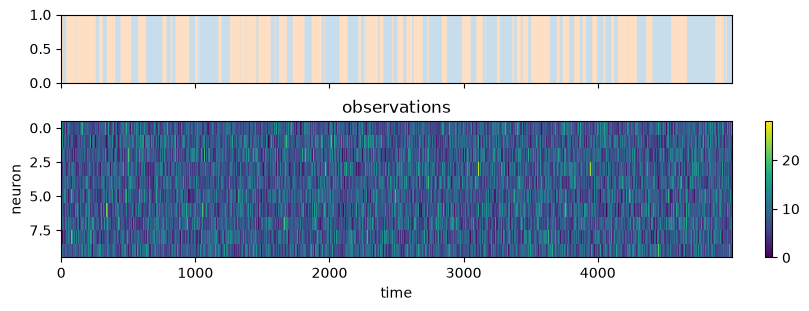

In [3]:
# def plot_latent(ax, latents, color='k', **kwargs):
#     ax.plot(latents[:, 0], latents[:, 1], color=color, **kwargs)
#     ax.scatter(latents[0, 0], latents[0, 1], color='g', zorder=10)
#     ax.scatter(latents[-1, 0], latents[-1, 1], color='r', zorder=10)
#     ax.set(title='latent states', aspect='equal')


def plot_state(ax, states, **kwargs):
    ax.imshow(
        states.reshape(-1, 1).T,
        aspect='auto',
        cmap=STATES_CMAP,
        vmin=0,
        vmax=2,
        alpha=0.25,
        extent=(0, len(states), 0, 1),
        transform=ax.get_xaxis_transform(),
    )


def plot_observations(ax, observations, **kwargs):
    im = ax.imshow(
        observations.T,
        aspect='auto',
        interpolation='none',
    )

    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xlabel='time',
        ylabel='neuron',
    )
    ax.set(title='observations')


def plot_data(true_states, observations):

    _f, axs = plt.subplots(
        nrows=2,
        sharex='all',
        figsize=(8, 3),
        constrained_layout=True,
        gridspec_kw={'height_ratios': [1, 2]},
    )

    ax = axs[0]

    plot_state(ax, true_states)

    ax = axs[1]
    plot_observations(ax, observations)


plot_data(true_states, observations)

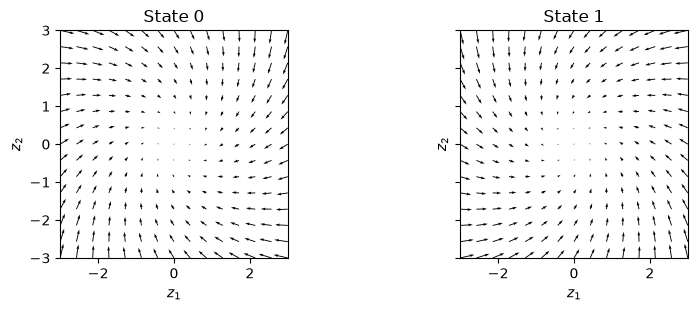

In [4]:
def plot_poisson_dynamics(
    ax,
    coefficients,
    bias,
    basis,
    baseline,
    xlim=(-3, 3),
    ylim=(-3, 3),
    num_points=15,
    **kwargs,
):
    """Plot projected expected displacement of 2D Poisson AR(1) dynamics."""
    coefficients = np.asarray(coefficients)
    bias = np.asarray(bias)
    basis = np.asarray(basis)
    baseline = np.asarray(baseline)

    x = np.linspace(*xlim, num_points)  # type: ignore
    y = np.linspace(*ylim, num_points)  # type: ignore
    xx, yy = np.meshgrid(x, y)

    # Coordinates in the 2D population subspace.
    z = np.stack([xx, yy], axis=-1)  # (..., 2)

    # Map into N-dimensional population activity around the fixed point.
    observations = baseline + z @ basis.T  # (..., N)

    # Expected next observation under the Poisson AR model.
    next_observations = np.exp(observations @ coefficients.T + bias)  # (..., N)

    # Project expected displacement back into the 2D subspace.
    displacement = (next_observations - observations) @ basis  # (..., 2)

    ax.quiver(
        xx,
        yy,
        displacement[..., 0],
        displacement[..., 1],
        **kwargs,
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$z_1$')
    ax.set_ylabel(r'$z_2$')


def plot_model_dynamics(model: Model) -> None:
    """Plot the expected displacement field of a 2D linear dynamics model."""

    _fig, axs = plt.subplots(
        ncols=model.emissions.num_states,
        figsize=(8, 3),
        sharex=True,
        sharey=True,
        constrained_layout=True,
        squeeze=False,
    )

    axs = axs.ravel()

    for state, ax in enumerate(axs):
        plot_poisson_dynamics(
            ax,
            coefficients=model.emissions.model.affine.coefficients[state],
            bias=model.emissions.model.affine.bias[state],
            basis=basis,
            baseline=baseline,
        )

        ax.set_title(f'State {state}')


plot_model_dynamics(true_model)

In [5]:
posterior, _ = infer_exact(true_model, observations)

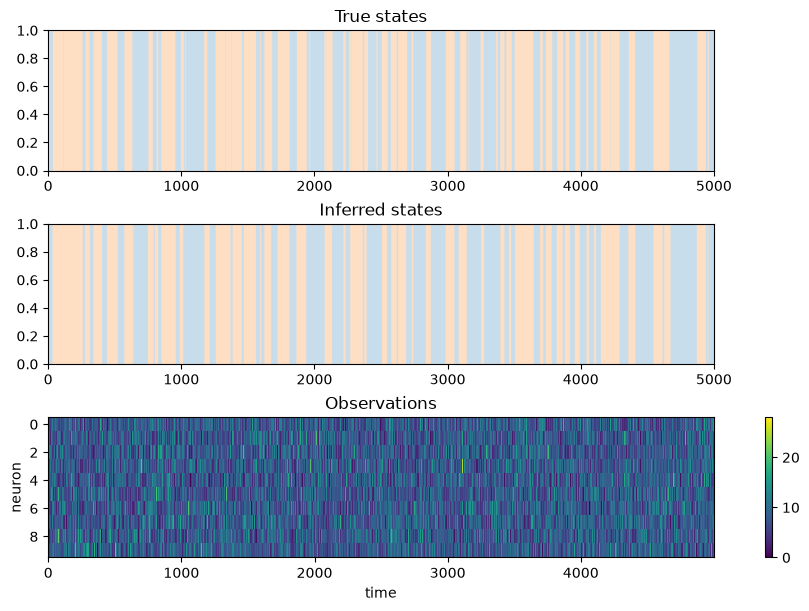

In [6]:
def plot_sequence_1d(
    ax,
    observations: jnp.ndarray,
    states: jnp.ndarray,
) -> None:
    observations = jnp.asarray(observations)
    states = jnp.asarray(states)

    ax.plot(observations.T[0], color='k')
    ax.plot(observations.T[1], color='xkcd:magenta')

    ax.set(xlabel='Time step', ylabel='Observations')


def plot_inferred_states(observations, true_states, posterior):
    _f, axs = plt.subplots(nrows=3, constrained_layout=True, figsize=(8, 6))

    ax = axs[0]
    plot_state(ax, true_states)
    ax.set(title='True states')

    ax = axs[1]

    inferred_states = posterior.state_probs.argmax(axis=1)
    plot_state(ax, inferred_states)
    ax.set(title='Inferred states')

    ax = axs[2]
    plot_observations(ax, observations)
    ax.set(title='Observations')


plot_inferred_states(observations, true_states, posterior)

EM:   0%|          | 0/100 [00:00<?, ?it/s]

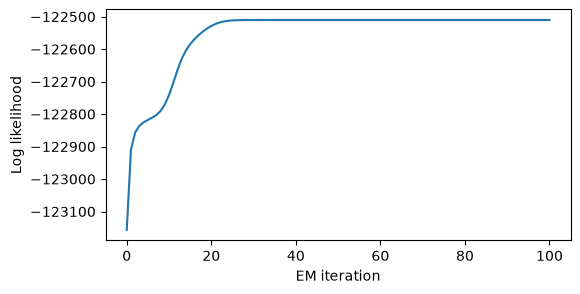

In [7]:
def plot_log_likelihood(log_likelihoods: jnp.ndarray) -> None:
    _f, ax = plt.subplots(figsize=(6, 3))

    ax.plot(np.asarray(log_likelihoods))

    ax.set_xlabel('EM iteration')
    ax.set_ylabel('Log likelihood')


initial_model = init_poisson_ar(
    observations=observations,
    num_states=true_model.num_states,
    key=jax.random.key(0),
    num_lags=1,
)


fit_em_jit = jax.jit(fit_em, static_argnames=['num_iters', 'progress'])

learned_model, log_likelihoods = fit_em_jit(
    model=initial_model,
    observations=observations,
    num_iters=100,
)


plot_log_likelihood(log_likelihoods)

In [8]:
permutation = match_states_by_conditional_mean(
    true_model.emissions.conditional(observations).log_rates,
    learned_model.emissions.conditional(observations).log_rates,
)

matched_model = learned_model.permute(permutation)

permutation

Array([0, 1], dtype=int32)

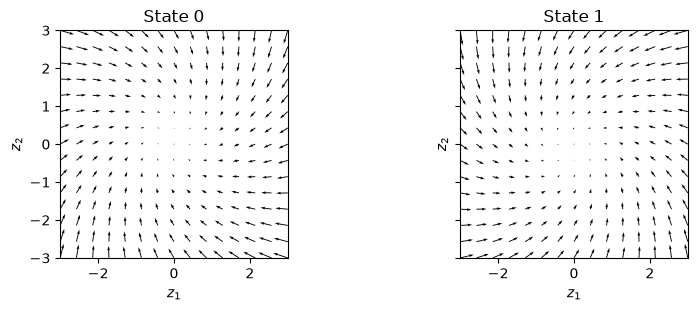

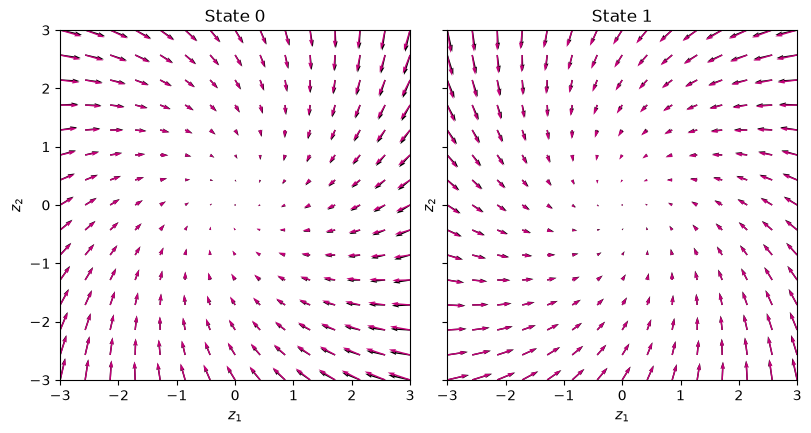

In [9]:
def plot_model_dynamics_comparison(model0: Model, model1: Model) -> None:
    """Plot the expected displacement field of a 2D linear dynamics model."""

    assert model0.num_states == model1.num_states, (
        'Models must have the same number of states.'
    )

    _fig, axs = plt.subplots(
        figsize=(8, 6),
        ncols=model0.num_states,
        sharex='all',
        sharey='all',
        constrained_layout=True,
        squeeze=False,
    )

    axs = axs.ravel()

    for state, ax in enumerate(axs):
        plot_poisson_dynamics(
            ax,
            coefficients=model0.emissions.model.affine.coefficients[state],
            bias=model0.emissions.model.affine.bias[state],
            basis=basis,
            baseline=baseline,
            color='k',
        )

        plot_poisson_dynamics(
            ax,
            coefficients=model1.emissions.model.affine.coefficients[state],
            bias=model1.emissions.model.affine.bias[state],
            basis=basis,
            baseline=baseline,
            color='xkcd:magenta',
        )

        ax.set_title(f'State {state}')


plot_model_dynamics(matched_model)
plot_model_dynamics_comparison(true_model, matched_model)

In [10]:
posterior_learnt, _ = infer_exact(matched_model, observations)

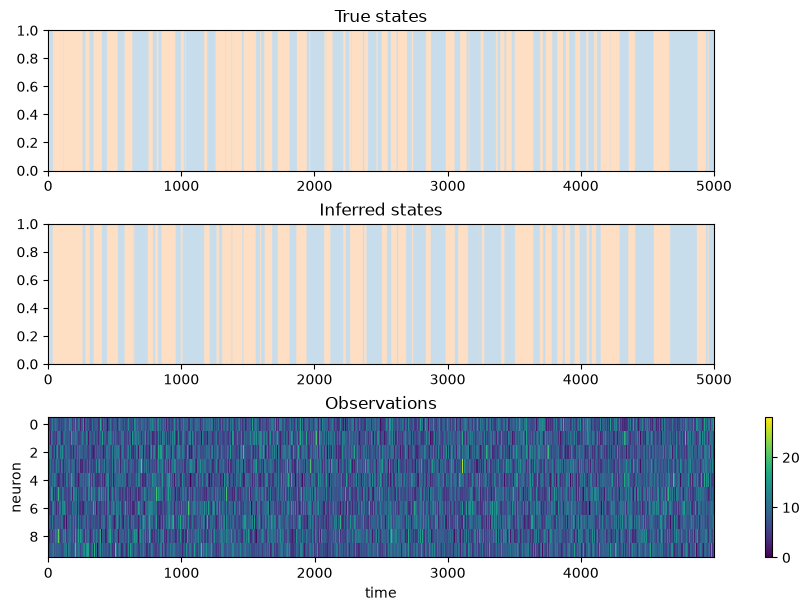

In [11]:
plot_inferred_states(observations, true_states, posterior_learnt)